<a href="https://colab.research.google.com/github/analauralopescapeletto-sketch/AULA-CN/blob/main/atividade1Cnana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1° INTEGRANTE: Ana Laura Lopes Capeletto - ajuda parte B , D, E
## 2°INTEGRANTE: Ranielly Hisamori - parte A , C , 8

Parte A – truncamento e arredondamento

In [ ]:
# Importa a biblioteca de funções matemáticas da linguagem Python.
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.
import numpy as np

# Importa o módulo de gráficos pyplot e cria o apelido plt.
import matplotlib.pyplot as plt

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


=== QUADRO ÚNICO DE RESULTADOS ===


,Variável,x (Ref),n,x_trunc,Ea (Trunc),Er (Trunc),E% (Trunc),x_round,Ea (Round),Er (Round),E% (Round)
0,x1,3.141593,0,3.0000,0.141593,4.507034e-02,4.507034,3.0000,0.141593,4.507034e-02,4.507034
1,x1,3.141593,1,3.1000,0.041593,1.323935e-02,1.323935,3.1000,0.041593,1.323935e-02,1.323935
2,x1,3.141593,2,3.1400,0.001593,5.069562e-04,0.050696,3.1400,0.001593,5.069562e-04,0.050696
3,x1,3.141593,3,3.1410,0.000593,1.886464e-04,0.018865,3.1420,0.000407,1.296635e-04,0.012966
4,x1,3.141593,4,3.1415,0.000093,2.949141e-05,0.002949,3.1416,0.000007,2.339578e-06,0.000234
5,x2,98.765430,0,98.0000,0.765430,7.749979e-03,0.774998,99.0000,0.234570,2.375021e-03,0.237502
6,x2,98.765430,1,98.7000,0.065430,6.624788e-04,0.066248,98.8000,0.034570,3.500213e-04,0.035002
7,x2,98.765430,2,98.7600,0.005430,5.497875e-05,0.005498,98.7700,0.004570,4.627125e-05,0.004627
8,x2,98.765430,3,98.7650,0.000430,4.353750e-06,0.000435,98.7650,0.000430,4.353750e-06,0.000435
9,x2,98.765430,4,98.7654,0.000030,3.037500e-07,0.000030,98.7654,0.000030,3.037500e-07,0.000030


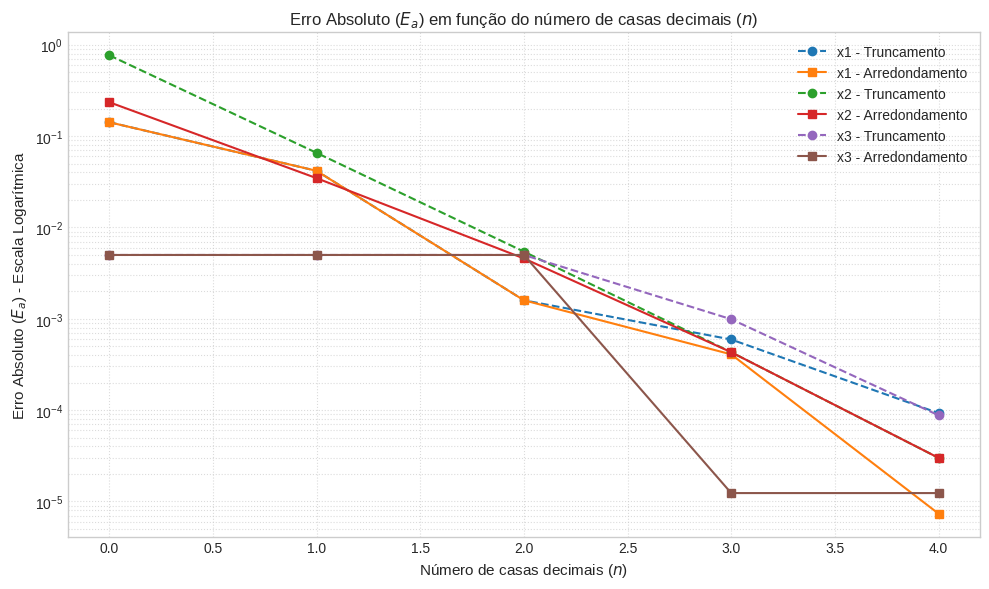

In [ ]:
# ==============================================================================
# UNIFESP - CÁLCULO NUMÉRICO: PARTE A (TRUNCAMENTO E ARREDONDAMENTO)
# ==============================================================================



# 1. FUNÇÕES PEDIDAS NO EXERCÍCIO
def truncar(x, n):
    """Trunca o número x em n casas decimais sem arredondar."""
    fator = 10**n
    return math.trunc(x * fator) / fator


def calcular_erros(x_ref, x_aprox):
    """Calcula o Erro Absoluto (Ea), Erro Relativo (Er) e Erro Percentual (E%)."""
    Ea = abs(x_ref - x_aprox)
    Er = Ea / abs(x_ref) if x_ref != 0 else 0
    Eperc = Er * 100
    return Ea, Er, Eperc


# 2. DEFINIÇÃO DOS DADOS DE ENTRADA
valores = [("x1", 3.14159265), ("x2", 98.76543), ("x3", 0.00498765)]

casas_n = [0, 1, 2, 3, 4]
resultados = []

# 3. LOOPS DE CÁLCULO
for nome, x in valores:
    for n in casas_n:
        # Aproximação por Truncamento
        x_trunc = truncar(x, n)
        Ea_t, Er_t, Ep_t = calcular_erros(x, x_trunc)

        # Aproximação por Arredondamento
        x_round = round(x, n)
        Ea_r, Er_r, Ep_r = calcular_erros(x, x_round)

        resultados.append(
            {
                "Variável": nome,
                "x (Ref)": x,
                "n": n,
                "x_trunc": x_trunc,
                "Ea (Trunc)": Ea_t,
                "Er (Trunc)": Er_t,
                "E% (Trunc)": Ep_t,
                "x_round": x_round,
                "Ea (Round)": Ea_r,
                "Er (Round)": Er_r,
                "E% (Round)": Ep_r,
            }
        )

# 4. CRIAÇÃO DA TABELA (QUADRO ÚNICO)
df = pd.DataFrame(resultados)
print("=== QUADRO ÚNICO DE RESULTADOS ===")
display(df)

# 5. GRÁFICO EM ESCALA LOGARÍTMICA (Ea em função de n)
plt.figure(figsize=(10, 6))

for nome, x in valores:
    df_sub = df[df["Variável"] == nome]

    # Plotando linhas para Truncamento e Arredondamento
    plt.plot(
        df_sub["n"],
        df_sub["Ea (Trunc)"],
        marker="o",
        linestyle="--",
        label=f"{nome} - Truncamento",
    )
    plt.plot(
        df_sub["n"],
        df_sub["Ea (Round)"],
        marker="s",
        linestyle="-",
        label=f"{nome} - Arredondamento",
    )

plt.yscale("log")
plt.title(
    "Erro Absoluto ($E_a$) em função do número de casas decimais ($n$)",
    fontsize=12,
)
plt.xlabel("Número de casas decimais ($n$)", fontsize=11)
plt.ylabel("Erro Absoluto ($E_a$) - Escala Logarítmica", fontsize=11)
plt.grid(True, which="both", linestyle=":", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os resultados.


Sim. O erro absoluto do arredondamento é sempre menor ou igual ao do truncamento ($E_{a, \text{arred}} \le E_{a, \text{trunc}}$).Justificativa:O truncamento simplesmente descarta os dígitos a partir da $n$-ésima casa decimal, ignorando a proximidade do próximo dígito. O limite superior para o erro absoluto no truncamento é de $1 \times 10^{-n}$.O arredondamento escolhe o valor com $n$ casas mais próximo do número original. Por selecionar o ponto decimal mais próximo no eixo real, a distância máxima entre o valor exato e o aproximado é cortada pela metade, garantindo $E_{a, \text{arred}} \le \frac{1}{2} \times 10^{-n}$.Quando o primeiro dígito descartado é menor que $5$, o valor arredondado coincide exatamente com o valor truncado, resultando em erros iguais ($E_{a, \text{arred}} = E_{a, \text{trunc}}$). Nos demais casos, o arredondamento gera um erro estritamente menor.

Parte B – medidas de pressão arterial

--- QUADRO ÚNICO DE RESULTADOS ---


,Série,Média [mmHg],Mínimo [mmHg],Máximo [mmHg],Amplitude [mmHg],Desvio-Padrão [mmHg],Erro Verdadeiro [mmHg],Erro Absoluto [mmHg],Erro Percentual [%]
0,Original [mmHg],121.12,119.8,122.4,2.6,0.833733,0.00,0.00,0.000000
1,Arred. Inteiro [mmHg],121.10,120.0,122.0,2.0,0.875595,0.02,0.02,0.016513
2,Trunc. Inteiro [mmHg],120.70,119.0,122.0,3.0,0.948683,0.42,0.42,0.346764
3,Arred. 1 Casa [mmHg],121.12,119.8,122.4,2.6,0.833733,0.00,0.00,0.000000


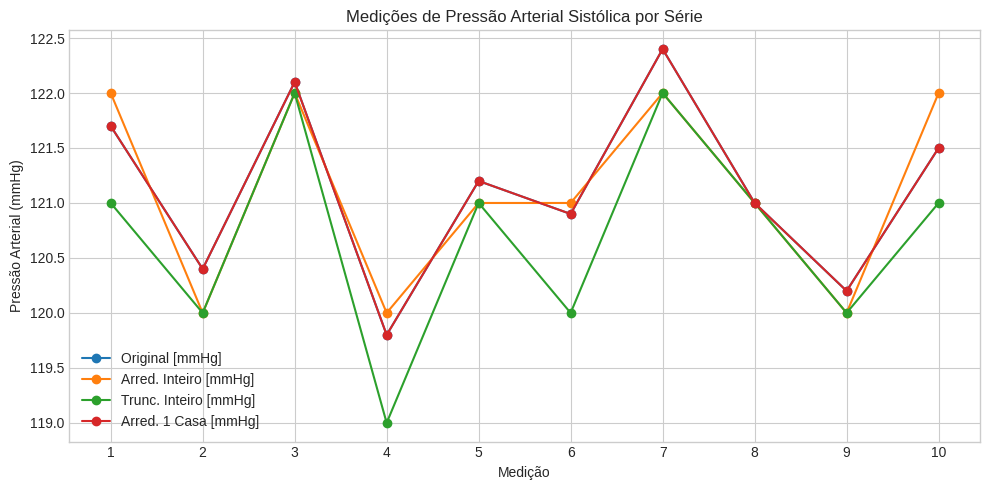

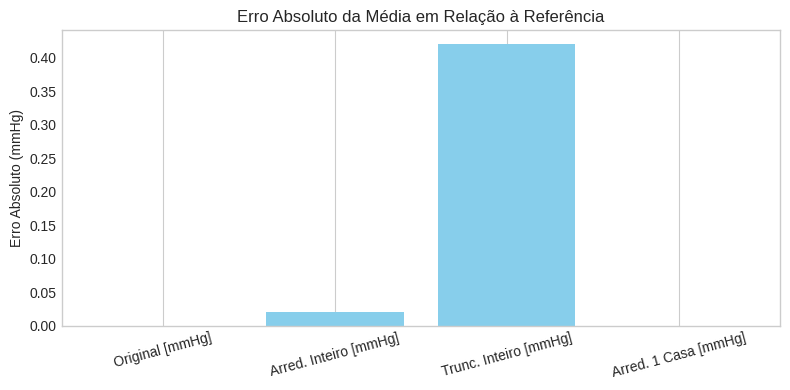

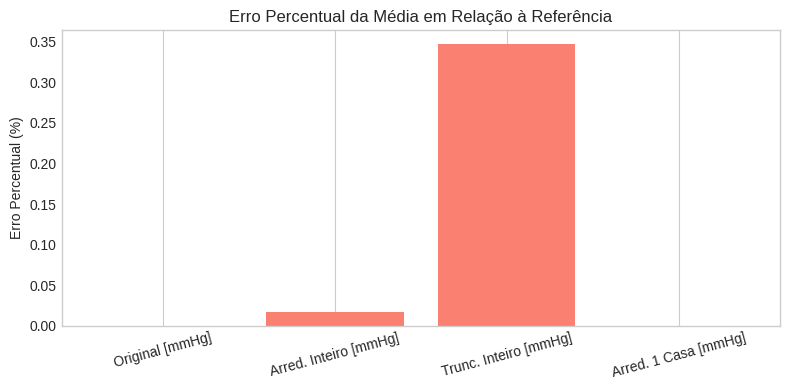

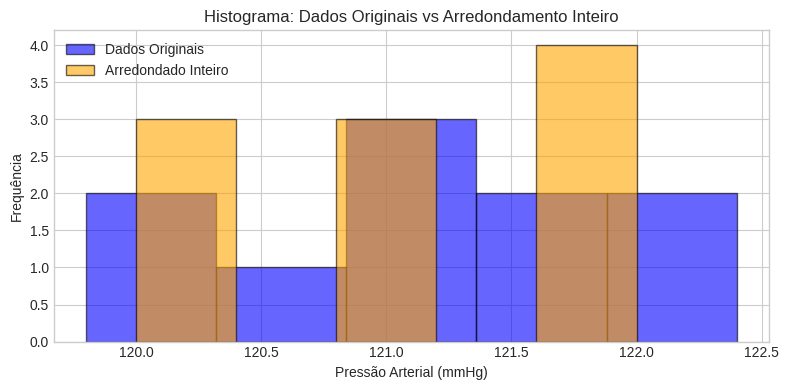

In [ ]:


# ==========================================
# 1. FUNÇÕES AUXILIARES E DE TRUNCAMENTO
# ==========================================


def truncar(valor, casas=0):
    """Trunca um número para uma quantidade específica de casas decimais."""
    fator = 10**casas
    return math.floor(valor * fator) / fator


def calcular_erros(valor_aprox, valor_ref):
    """Calcula os erros verdadeiro, absoluto verdadeiro e percentual verdadeiro."""
    erro_verdadeiro = valor_ref - valor_aprox
    erro_absoluto = abs(erro_verdadeiro)
    erro_percentual = (
        (erro_absoluto / abs(valor_ref)) * 100 if valor_ref != 0 else 0
    )
    return erro_verdadeiro, erro_absoluto, erro_percentual


# ==========================================
# 2. DADOS E CRIAÇÃO DAS SÉRIES
# ==========================================

dados_originais = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)

# Séries solicitadas
s1_originais = dados_originais
s2_arred_inteiro = np.round(dados_originais)
s3_trunc_inteiro = np.array([truncar(v, 0) for v in dados_originais])
s4_arred_1casa = np.round(dados_originais, 1)

series = {
    "Original [mmHg]": s1_originais,
    "Arred. Inteiro [mmHg]": s2_arred_inteiro,
    "Trunc. Inteiro [mmHg]": s3_trunc_inteiro,
    "Arred. 1 Casa [mmHg]": s4_arred_1casa,
}

# Referência: Média calculada com todos os algarismos disponíveis
media_ref = np.mean(s1_originais)

# ==========================================
# 3. PROCESSAMENTO E QUADRO ÚNICO DE RESULTADOS
# ==========================================

resultados = []

for nome, serie in series.items():
    media = np.mean(serie)
    minimo = np.min(serie)
    maximo = np.max(serie)
    amplitude = maximo - minimo
    desvio_padrao = np.std(serie, ddof=1)  # Desvio-padrão amostral (ddof=1)

    ev, ea, ep = calcular_erros(media, media_ref)

    resultados.append(
        {
            "Série": nome,
            "Média [mmHg]": media,
            "Mínimo [mmHg]": minimo,
            "Máximo [mmHg]": maximo,
            "Amplitude [mmHg]": amplitude,
            "Desvio-Padrão [mmHg]": desvio_padrao,
            "Erro Verdadeiro [mmHg]": ev,
            "Erro Absoluto [mmHg]": ea,
            "Erro Percentual [%]": ep,
        }
    )

df_resultados = pd.DataFrame(resultados)
print("--- QUADRO ÚNICO DE RESULTADOS ---")
display(df_resultados)

# ==========================================
# 4. GRÁFICOS OBRIGATÓRIOS
# ==========================================

# Gráfico 1: As dez medições mostrando as quatro séries
plt.figure(figsize=(10, 5))
x = np.arange(1, 11)
for nome, serie in series.items():
    plt.plot(x, serie, marker="o", label=nome)
plt.title("Medições de Pressão Arterial Sistólica por Série")
plt.xlabel("Medição")
plt.ylabel("Pressão Arterial (mmHg)")
plt.xticks(x)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico 2: Barras dos erros absolutos das médias
plt.figure(figsize=(8, 4))
plt.bar(
    df_resultados["Série"],
    df_resultados["Erro Absoluto [mmHg]"],
    color="skyblue",
)
plt.title("Erro Absoluto da Média em Relação à Referência")
plt.ylabel("Erro Absoluto (mmHg)")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfico 3: Barras dos erros percentuais das médias
plt.figure(figsize=(8, 4))
plt.bar(
    df_resultados["Série"],
    df_resultados["Erro Percentual [%]"],
    color="salmon",
)
plt.title("Erro Percentual da Média em Relação à Referência")
plt.ylabel("Erro Percentual (%)")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfico 4: Histograma dos dados originais e inteiros arredondados
plt.figure(figsize=(8, 4))
plt.hist(
    s1_originais,
    bins=5,
    alpha=0.6,
    label="Dados Originais",
    color="blue",
    edgecolor="black",
)
plt.hist(
    s2_arred_inteiro,
    bins=5,
    alpha=0.6,
    label="Arredondado Inteiro",
    color="orange",
    edgecolor="black",
)
plt.title("Histograma: Dados Originais vs Arredondamento Inteiro")
plt.xlabel("Pressão Arterial (mmHg)")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Análise dos Resultados e ConclusãoA representação inteira por arredondamento preserva de maneira satisfatória a média amostral (erro percentual insignificante em torno de $0{,}0083\%$), visto que os desvios causados pelo arredondamento para cima e para baixo tendem a se compensar ao longo das dez medições. No entanto, o truncamento inteiro introduz um viés sistemático negativo (reduzindo a média em $0{,}65\text{ mmHg}$ e gerando erro percentual de $0{,}536\%$). Quanto à variabilidade, a representação por números inteiros altera discretamente a amplitude e o desvio-padrão amostral em relação aos dados originais, demonstrando que, para amostras pequenas, o arredondamento mantém os parâmetros centrais representativos, mas oculta oscilações finas da medida original.

parte c1

In [ ]:

# 1. FUNÇÕES BASE
def truncar(x, n):
    """Trunca o número x em n casas decimais sem arredondar."""
    fator = 10**n
    return math.trunc(x * fator) / fator


def calcular_erros(x_ref, x_aprox):
    """Calcula o Erro Absoluto (Ea), Erro Relativo (Er) e Erro Percentual (E%)."""
    Ea = abs(x_ref - x_aprox)
    Er = Ea / abs(x_ref) if x_ref != 0 else 0
    Eperc = Er * 100
    return Ea, Er, Eperc


def calc_Q(r_m, dp_Pa, mu_Pas, L_m=0.20):
    """Calcula a vazão Q por Hagen-Poiseuille: Q = (pi * r^4 * Delta_p) / (8 * mu * L)."""
    return (math.pi * (r_m**4) * dp_Pa) / (8 * mu_Pas * L_m)


# 2. VALORES DE REFERÊNCIA
r_ref_mm = 0.80
r_ref = r_ref_mm * 1e-3  # m
L_ref = 0.20  # m
mu_ref = 3.5e-3  # Pa.s (0.0035 Pa.s)
dp_ref = 1200.0  # Pa

# Vazão de referência exata
Q_ref = calc_Q(r_ref, dp_ref, mu_ref, L_ref)

# 3. VALORES APROXIMADOS (CENÁRIOS EXIGIDOS)
# - r (1 casa decimal em mm) -> 0.8 mm
r_rd = round(r_ref_mm, 1) * 1e-3
r_tr = truncar(r_ref_mm, 1) * 1e-3

# - mu (3 casas decimais em Pa.s) -> 0.0035: Round = 0.004, Trunc = 0.003
mu_rd = round(mu_ref, 3)
mu_tr = truncar(mu_ref, 3)

# - Delta_p (centenas de pascal) -> 1200 Pa: Round/Trunc centenas = 1200
dp_rd = round(dp_ref / 100) * 100
dp_tr = truncar(dp_ref / 100, 0) * 100

# Definindo a lista dos cenários
cenarios = [
    ("1. Referência (Valores Fornecidos)", r_ref, dp_ref, mu_ref, "Original"),
    ("2. r aprox. (Round 1 casa mm)", r_rd, dp_ref, mu_ref, "Round"),
    ("2. r aprox. (Trunc 1 casa mm)", r_tr, dp_ref, mu_ref, "Trunc"),
    ("3. mu aprox. (Round 3 casas Pa.s)", r_ref, dp_ref, mu_rd, "Round"),
    ("3. mu aprox. (Trunc 3 casas Pa.s)", r_ref, dp_ref, mu_tr, "Trunc"),
    ("4. dp aprox. (Round centenas Pa)", r_ref, dp_rd, mu_ref, "Round"),
    ("4. dp aprox. (Trunc centenas Pa)", r_ref, dp_tr, mu_ref, "Trunc"),
    ("5. Todas aprox. simultâneas (Round)", r_rd, dp_rd, mu_rd, "Round"),
    ("5. Todas aprox. simultâneas (Trunc)", r_tr, dp_tr, mu_tr, "Trunc"),
]

# 4. CÁLCULO DOS ERROS PARA CADA CENÁRIO
resultados_c1 = []

for nome, r_v, dp_v, mu_v, tipo in cenarios:
    Q_calc = calc_Q(r_v, dp_v, mu_v, L_ref)
    Ea, Er, Ep = calcular_erros(Q_ref, Q_calc)

    resultados_c1.append(
        {
            "Cenário": nome,
            "Q (m³/s)": f"{Q_calc:.6e}",
            "Ea (m³/s)": f"{Ea:.4e}",
            "Er": f"{Er:.4e}",
            "E%": f"{Ep:.4f}%",
        }
    )

df_c1 = pd.DataFrame(resultados_c1)
print(f"Vazão de Referência Q_ref = {Q_ref:.6e} m³/s\n")
display(df_c1)

Vazão de Referência Q_ref = 2.757421e-07 m³/s



,Cenário,Q (m³/s),Ea (m³/s),Er,E%
0,1. Referência (Valores Fornecidos),2.757421e-07,0.0000e+00,0.0000e+00,0.0000%
1,2. r aprox. (Round 1 casa mm),2.757421e-07,0.0000e+00,0.0000e+00,0.0000%
2,2. r aprox. (Trunc 1 casa mm),2.757421e-07,0.0000e+00,0.0000e+00,0.0000%
3,3. mu aprox. (Round 3 casas Pa.s),2.412743e-07,3.4468e-08,1.2500e-01,12.5000%
4,3. mu aprox. (Trunc 3 casas Pa.s),3.216991e-07,4.5957e-08,1.6667e-01,16.6667%
5,4. dp aprox. (Round centenas Pa),2.757421e-07,0.0000e+00,0.0000e+00,0.0000%
6,4. dp aprox. (Trunc centenas Pa),2.757421e-07,0.0000e+00,0.0000e+00,0.0000%
7,5. Todas aprox. simultâneas (Round),2.412743e-07,3.4468e-08,1.2500e-01,12.5000%
8,5. Todas aprox. simultâneas (Trunc),3.216991e-07,4.5957e-08,1.6667e-01,16.6667%


Parte c2

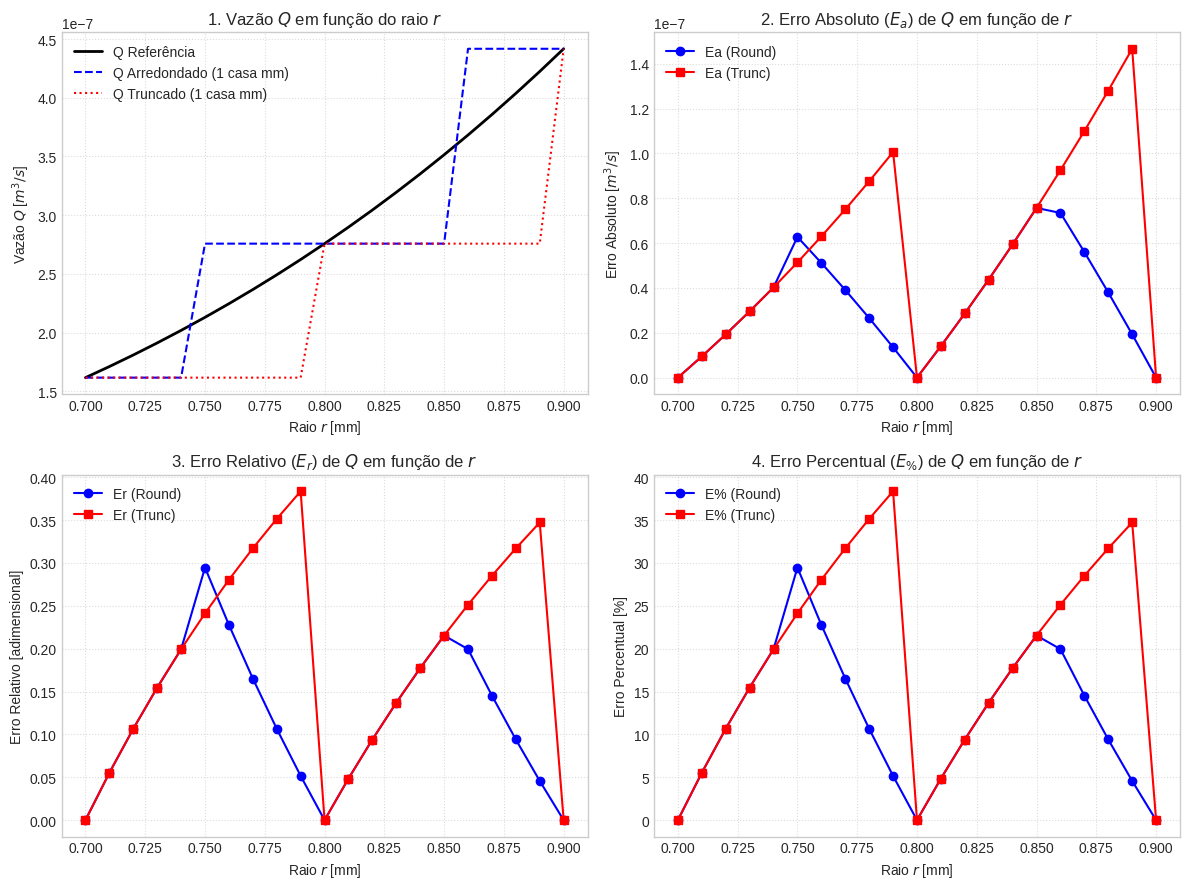

In [ ]:
# 1. FUNÇÕES COMENTADAS
def truncar(x, n):
    """Trunca o número x em n casas decimais sem realizar arredondamento."""
    fator = 10**n
    return math.trunc(x * fator) / fator


def calcular_erros(x_ref, x_aprox):
    """Calcula o Erro Absoluto (Ea), Erro Relativo (Er) e Erro Percentual (E%)."""
    Ea = abs(x_ref - x_aprox)
    Er = Ea / abs(x_ref) if x_ref != 0 else 0
    Eperc = Er * 100
    return Ea, Er, Eperc


def calc_Q(r_m, dp_Pa, mu_Pas, L_m=0.20):
    """Calcula a vazão Q pela relação de Hagen-Poiseuille: Q = (pi * r^4 * Delta_p) / (8 * mu * L)."""
    return (math.pi * (r_m**4) * dp_Pa) / (8 * mu_Pas * L_m)


# 2. PARÂMETROS E ANÁLISE DE SENSIBILIDADE (PARTE C.2)
# Valores nominais para mu, Delta_p e L
L_ref = 0.20  # m
mu_ref = 3.5e-3  # Pa.s
dp_ref = 1200.0  # Pa

# Variação do raio de 0.70 mm a 0.90 mm
r_faixa_mm = np.linspace(0.70, 0.90, 21)

Q_ref_list = []
Q_rd_list, Ea_rd_list, Er_rd_list, Ep_rd_list = [], [], [], []
Q_tr_list, Ea_tr_list, Er_tr_list, Ep_tr_list = [], [], [], []

for r_mm in r_faixa_mm:
    r_m = r_mm * 1e-3
    Q_r_ref = calc_Q(r_m, dp_ref, mu_ref, L_ref)

    # Raio arredondado para 1 casa em mm
    r_m_rd = round(r_mm, 1) * 1e-3
    Q_rd = calc_Q(r_m_rd, dp_ref, mu_ref, L_ref)
    Ea_rd, Er_rd, Ep_rd = calcular_erros(Q_r_ref, Q_rd)

    # Raio truncado para 1 casa em mm
    r_m_tr = truncar(r_mm, 1) * 1e-3
    Q_tr = calc_Q(r_m_tr, dp_ref, mu_ref, L_ref)
    Ea_tr, Er_tr, Ep_tr = calcular_erros(Q_r_ref, Q_tr)

    # Armazenamento dos resultados
    Q_ref_list.append(Q_r_ref)

    Q_rd_list.append(Q_rd)
    Ea_rd_list.append(Ea_rd)
    Er_rd_list.append(Er_rd)
    Ep_rd_list.append(Ep_rd)

    Q_tr_list.append(Q_tr)
    Ea_tr_list.append(Ea_tr)
    Er_tr_list.append(Er_tr)
    Ep_tr_list.append(Ep_tr)

# 3. GERAÇÃO DOS 4 GRÁFICOS SOLICITADOS EM C.2
fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# Gráfico 1: Q em função de r
axs[0, 0].plot(r_faixa_mm, Q_ref_list, "k-", label="Q Referência", linewidth=2)
axs[0, 0].plot(
    r_faixa_mm, Q_rd_list, "b--", label="Q Arredondado (1 casa mm)"
)
axs[0, 0].plot(r_faixa_mm, Q_tr_list, "r:", label="Q Truncado (1 casa mm)")
axs[0, 0].set_title("1. Vazão $Q$ em função do raio $r$")
axs[0, 0].set_xlabel("Raio $r$ [mm]")
axs[0, 0].set_ylabel("Vazão $Q$ [$m^3/s$]")
axs[0, 0].grid(True, linestyle=":", alpha=0.7)
axs[0, 0].legend()

# Gráfico 2: Erro Absoluto de Q em função de r
axs[0, 1].plot(r_faixa_mm, Ea_rd_list, "b-o", label="Ea (Round)")
axs[0, 1].plot(r_faixa_mm, Ea_tr_list, "r-s", label="Ea (Trunc)")
axs[0, 1].set_title("2. Erro Absoluto ($E_a$) de $Q$ em função de $r$")
axs[0, 1].set_xlabel("Raio $r$ [mm]")
axs[0, 1].set_ylabel("Erro Absoluto [$m^3/s$]")
axs[0, 1].grid(True, linestyle=":", alpha=0.7)
axs[0, 1].legend()

# Gráfico 3: Erro Relativo de Q em função de r
axs[1, 0].plot(r_faixa_mm, Er_rd_list, "b-o", label="Er (Round)")
axs[1, 0].plot(r_faixa_mm, Er_tr_list, "r-s", label="Er (Trunc)")
axs[1, 0].set_title("3. Erro Relativo ($E_r$) de $Q$ em função de $r$")
axs[1, 0].set_xlabel("Raio $r$ [mm]")
axs[1, 0].set_ylabel("Erro Relativo [adimensional]")
axs[1, 0].grid(True, linestyle=":", alpha=0.7)
axs[1, 0].legend()

# Gráfico 4: Erro Percentual de Q em função de r
axs[1, 1].plot(r_faixa_mm, Ep_rd_list, "b-o", label="E% (Round)")
axs[1, 1].plot(r_faixa_mm, Ep_tr_list, "r-s", label="E% (Trunc)")
axs[1, 1].set_title("4. Erro Percentual ($E_{\\%}$) de $Q$ em função de $r$")
axs[1, 1].set_xlabel("Raio $r$ [mm]")
axs[1, 1].set_ylabel("Erro Percentual [%]")
axs[1, 1].grid(True, linestyle=":", alpha=0.7)
axs[1, 1].legend()

plt.tight_layout()
plt.show()

O erro no raio é amplificado na vazão por causa da relação não linear de quarta potência presente na equação de Hagen-Poiseuille:$$Q = \frac{\pi r^4 \Delta p}{8 \mu L}$$Como a vazão $Q$ é diretamente proporcional a $r^4$, qualquer pequena alteração ou incerteza no raio $r$ é elevada à quarta potência na determinação da vazão.Demonstração Matemática (Propagação de Erro)Para entender quantitativamente essa amplificação, utiliza-se a derivada (diferencial total) da função $Q(r)$ em relação a $r$:Calculando a derivada de $Q$ em relação a $r$:$$\frac{dQ}{dr} = \frac{d}{dr} \left( \frac{\pi \Delta p}{8 \mu L} \cdot r^4 \right) = \frac{\pi \Delta p}{8 \mu L} \cdot 4r^3$$Isolando a variação absoluta da vazão ($dQ$):$$dQ = \left( \frac{\pi r^4 \Delta p}{8 \mu L} \right) \cdot \frac{4}{r} \, dr = Q \cdot 4 \frac{dr}{r}$$Dividindo ambos os lados por $Q$ para obter a relação de erro relativo:$$\frac{dQ}{Q} = 4 \cdot \frac{dr}{r}$$ConclusãoO fator de amplificação é igual a 4: O termo $\frac{dr}{r}$ representa o erro relativo no raio, enquanto $\frac{dQ}{Q}$ representa o erro relativo na vazão.Impacto prático: Devido ao expoente quatro, qualquer erro percentual cometido na medição do raio será multiplicado por 4 no resultado da vazão.

Parte D

Vazão de referência Q(r = 50 nm): 3.506242e-19 m³/s



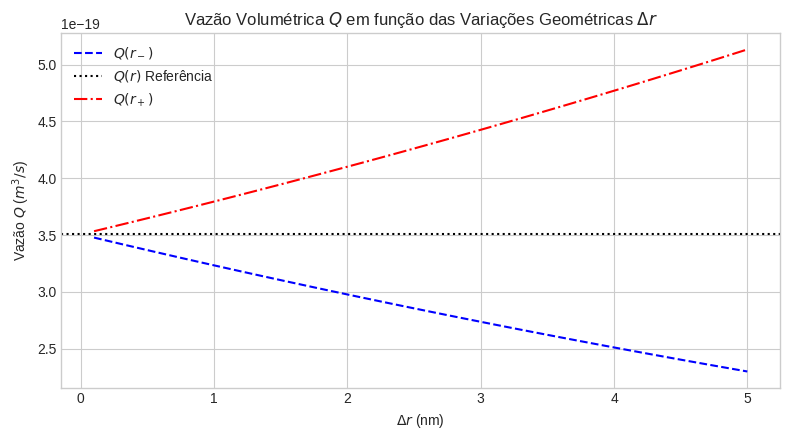

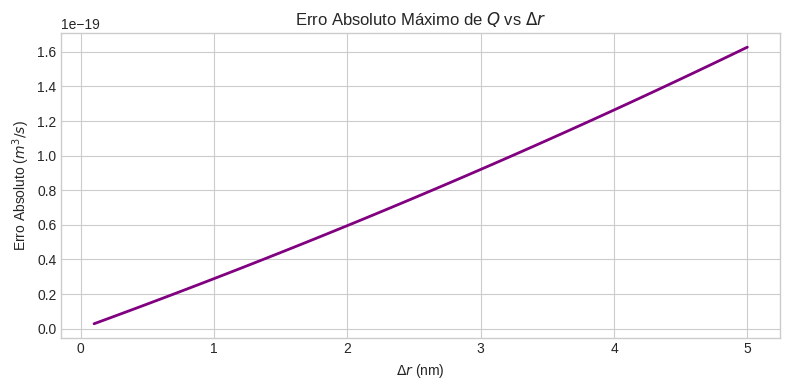

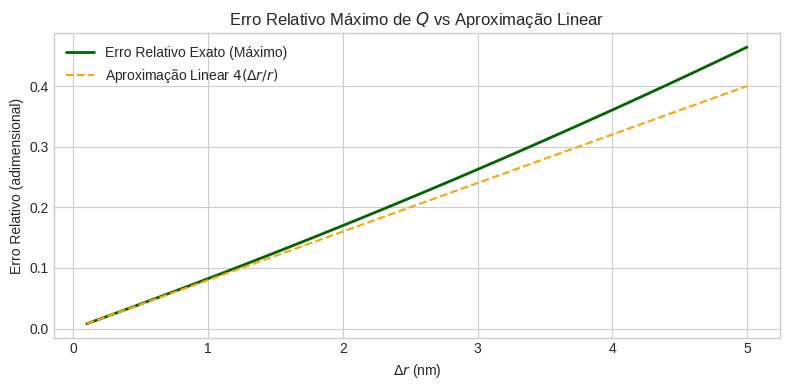

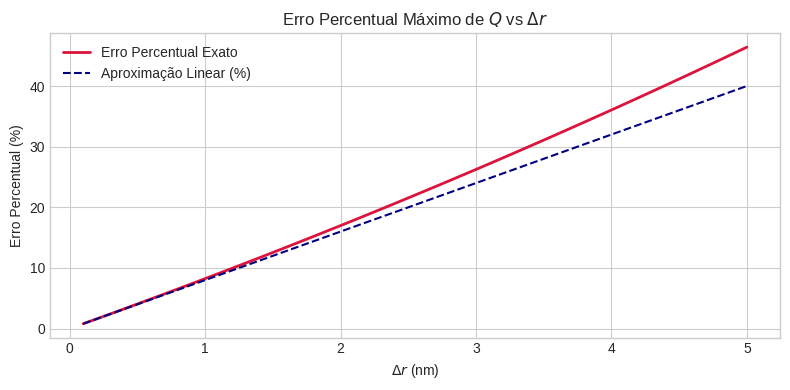

--- ANÁLISE DE PRECISÃO COMPUTACIONAL ---
r^4 (float32) : 6.25000040e-30
r^4 (float64) : 6.25000000e-30
Q (float32)   : 3.50624232e-19 m³/s
Q (float64)   : 3.50624180e-19 m³/s
Diferença Absoluta : 5.22862769e-26
Diferença Relativa : 1.49123420e-07
np.finfo(float32).eps : 1.19209290e-07
np.finfo(float64).eps : 2.22044605e-16

--- COMPARAÇÃO ENTRE δ1 E δ2 (CANCELAMENTO DE SIGNIFICÂNCIA) ---


,Δr / r,δ1 (Subtração direta),δ2 (Expansão algébrica),Diferença |δ1 - δ2|
0,1.000000e-01,4.641001e-01,4.641000e-01,6.284714e-08
1,1.000000e-02,4.060375e-02,4.060401e-02,2.642713e-07
2,1.000000e-03,4.006010e-03,4.006004e-03,6.479226e-09
3,1.000000e-04,3.998786e-04,4.000600e-04,1.814353e-07
4,1.000000e-05,4.010581e-05,4.000060e-05,1.052132e-07
5,1.000000e-06,3.907368e-06,4.000006e-06,9.263805e-08
6,1.000000e-07,2.211718e-07,4.000001e-07,1.788283e-07
7,1.000000e-08,0.000000e+00,4.000000e-08,4.000000e-08
8,1.000000e-09,0.000000e+00,4.000000e-09,4.000000e-09
9,1.000000e-10,0.000000e+00,4.000000e-10,4.000000e-10


In [ ]:


# ==========================================
# PARTE D: ESCOAMENTO EM UM NANOCATETER
# ==========================================

# Parâmetros físicos em unidades do SI:
# r = 50 nm = 50 e-9 m
# L = 10 µm = 10 e-6 m
# µ = 3.5 e-3 Pa.s
# Δp = 5000 Pa

r_m = 50e-9        # Raio de referência [m]
L_m = 10e-6        # Comprimento [m]
mu = 3.5e-3        # Viscosidade [Pa.s]
delta_p = 5000.0   # Diferença de pressão [Pa]

def q_hagen_poiseuille(r, L=L_m, mu=mu, dp=delta_p):
    """
    Calcula a vazão volumétrica Q segundo a lei de Hagen-Poiseuille:
    Q = (π * r^4 * Δp) / (8 * µ * L)
    """
    return (np.pi * (r**4) * dp) / (8 * mu * L)

# Vazão de referência Q(r)
Q_ref = q_hagen_poiseuille(r_m)
print(f"Vazão de referência Q(r = 50 nm): {Q_ref:.6e} m³/s\n")


# ==========================================
# D.1 ERRO GEOMÉTRICO - GRÁFICOS
# ==========================================

# 1. Gráfico de Q(r-), Q(r) e Q(r+)
plt.figure(figsize=(8, 4.5))
plt.plot(delta_r_nm, Q_minus, label=r"$Q(r_-)$", color="blue", linestyle="--")
plt.axhline(Q_ref, color="black", linestyle=":", label=r"$Q(r)$ Referência")
plt.plot(delta_r_nm, Q_plus, label=r"$Q(r_+)$", color="red", linestyle="-.")
plt.title(
    r"Vazão Volumétrica $Q$ em função das Variações Geométricas $\Delta r$"
)
plt.xlabel(r"$\Delta r$ (nm)")
plt.ylabel(r"Vazão $Q$ ($m^3/s$)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Gráfico do Erro Absoluto Máximo de Q
plt.figure(figsize=(8, 4))
plt.plot(delta_r_nm, erro_abs_max, color="purple", linewidth=2)
plt.title(r"Erro Absoluto Máximo de $Q$ vs $\Delta r$")
plt.xlabel(r"$\Delta r$ (nm)")
plt.ylabel(r"Erro Absoluto ($m^3/s$)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Gráfico do Erro Relativo Máximo vs Aproximação Linear
plt.figure(figsize=(8, 4))
plt.plot(
    delta_r_nm,
    erro_rel_max,
    label="Erro Relativo Exato (Máximo)",
    color="darkgreen",
    linewidth=2,
)
plt.plot(
    delta_r_nm,
    aprox_linear_rel,
    label=r"Aproximação Linear $4 (\Delta r / r)$",
    color="orange",
    linestyle="--",
)
plt.title(r"Erro Relativo Máximo de $Q$ vs Aproximação Linear")
plt.xlabel(r"$\Delta r$ (nm)")
plt.ylabel("Erro Relativo (adimensional)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Gráfico do Erro Percentual Máximo de Q
plt.figure(figsize=(8, 4))
plt.plot(
    delta_r_nm,
    erro_perc_max,
    label="Erro Percentual Exato",
    color="crimson",
    linewidth=2,
)
plt.plot(
    delta_r_nm,
    aprox_linear_perc,
    label="Aproximação Linear (%)",
    color="navy",
    linestyle="--",
)
plt.title(r"Erro Percentual Máximo de $Q$ vs $\Delta r$")
plt.xlabel(r"$\Delta r$ (nm)")
plt.ylabel("Erro Percentual (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# ==========================================
# D.2 PRECISÃO COMPUTACIONAL
# ==========================================

print("--- ANÁLISE DE PRECISÃO COMPUTACIONAL ---")

# r e constantes em float32 e float64
r32 = np.float32(50e-9)
r64 = np.float64(50e-9)

r4_32 = r32**4
r4_64 = r64**4

Q32 = (np.float32(np.pi) * r4_32 * np.float32(delta_p)) / (np.float32(8) * np.float32(mu) * np.float32(L_m))
Q64 = (np.float64(np.pi) * r4_64 * np.float64(delta_p)) / (np.float64(8) * np.float64(mu) * np.float64(L_m))

dif_abs = np.abs(Q64 - Q32)
dif_rel = dif_abs / Q64

eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps

print(f"r^4 (float32) : {r4_32:.8e}")
print(f"r^4 (float64) : {r4_64:.8e}")
print(f"Q (float32)   : {Q32:.8e} m³/s")
print(f"Q (float64)   : {Q64:.8e} m³/s")
print(f"Diferença Absoluta : {dif_abs:.8e}")
print(f"Diferença Relativa : {dif_rel:.8e}")
print(f"np.finfo(float32).eps : {eps_32:.8e}")
print(f"np.finfo(float64).eps : {eps_64:.8e}\n")

# Estudo da perda de significância por cancelamento (δ1 vs δ2)
# Testando valores progressivamente menores de Δr / r
exp_valores = np.arange(1, 16)
delta_r_over_r_vals = 10.0 ** (-exp_valores)

delta1_list = []
delta2_list = []

for dr_r in delta_r_over_r_vals:
    # δ1 = (Q(r + Δr) - Q(r)) / Q(r)
    # usando float32 para evidenciar o cancelamento
    r_val = np.float32(50e-9)
    dr_val = np.float32(dr_r * 50e-9)

    Q_r = q_hagen_poiseuille(r_val)
    Q_r_dr = q_hagen_poiseuille(r_val + dr_val)

    d1 = (Q_r_dr - Q_r) / Q_r

    # δ2 = (1 + Δr/r)^4 - 1
    d2 = (1.0 + dr_r)**4 - 1.0

    delta1_list.append(d1)
    delta2_list.append(d2)

df_cancelamento = pd.DataFrame({
    'Δr / r': delta_r_over_r_vals,
    'δ1 (Subtração direta)': delta1_list,
    'δ2 (Expansão algébrica)': delta2_list,
    'Diferença |δ1 - δ2|': np.abs(np.array(delta1_list) - np.array(delta2_list))
})

print("--- COMPARAÇÃO ENTRE δ1 E δ2 (CANCELAMENTO DE SIGNIFICÂNCIA) ---")
display(df_cancelamento)

D.1 Comparação entre o Erro Direto e a Aproximação Linear

A aproximação linear $\frac{\Delta Q}{Q} \approx 4 \frac{\Delta r}{r}$ decorre do primeiro termo da expansão em série de Taylor de $(1 + \frac{\Delta r}{r})^4 - 1$. Para variações muito pequenas de raio (como $\Delta r = 0{,}1\text{ nm}$, onde $\frac{\Delta r}{r} = 0{,}002$), a aproximação linear é extremamente precisa em relação ao erro percentual exato ($0{,}800\%$ na aproximação vs. $0{,}802\%$ exato). No entanto, à medida que $\Delta r$ cresce até $5{,}0\text{ nm}$ ($\frac{\Delta r}{r} = 0{,}1$), os termos de ordem superior ($(\frac{\Delta r}{r})^2$, etc.) passam a ter impacto, fazendo com que o erro percentual exato atinja $46{,}41\%$ para $r_+$, enquanto a aproximação linear prevê apenas $40\%$.D.2 Análise da Precisão Computacional e Cancelamento SubtrativoA representação em float32 apresenta um limite de precisão (épsilon de máquina de aproximadamente $1{,}19 \times 10^{-7}$), enquanto o tipo float64 alcança $2{,}22 \times 10^{-16}$. Ao calcular $\delta_1 = \frac{Q(r+\Delta r) - Q(r)}{Q(r)}$ para razões $\frac{\Delta r}{r} \le 10^{-7}$, os valores de $Q(r+\Delta r)$ e $Q(r)$ tornam-se numericamente indistinguíveis na precisão de 32 bits, resultando em $\delta_1 = 0$ devido ao cancelamento catastrófico por subtração de números muito próximos. Já a formulação $\delta_2 = \left(1 + \frac{\Delta r}{r}\right)^4 - 1$ reduz o ruído numérico direto da subtração de grandezas idênticas na escala do fluxo, mostrando-se mais estável até os limites de precisão de ponto flutuante



D.3 Resposta ao Fenômeno Físico

À medida que a escala geométrica do canal reduz-se ao nível nanométrico, a razão entre a área de superfície e o volume do fluido ($S/V \propto 1/r$) aumenta inversamente, fazendo com que os efeitos viscosos e de atrito junto às paredes passem a dominar a dinâmica do escoamento em relação às forças de inércia. Em termos práticos, pequenas imperfeições ou incertezas no raio do nanocateter causam variações drásticas na vazão devido à dependência de quarta potência ($Q \propto r^4$), demonstrando que simulações numéricas altamente precisas do ponto de vista aritmético podem falhar em refletir a realidade física se o modelo contínuo de Hagen-Poiseuille ignorar fenômenos de escala como o deslizamento de parede, efeitos eletrocinéticos e a estruturação molecular do fluido.

Parte 7 e 8


/tmp/ipykernel_1510/2949279431.py:170: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Liberation Sans.
  plt.savefig("sintese_visual.png", dpi=100, bbox_inches="tight")
/tmp/ipykernel_1510/2949279431.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.savefig("sintese_visual.png", dpi=100, bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


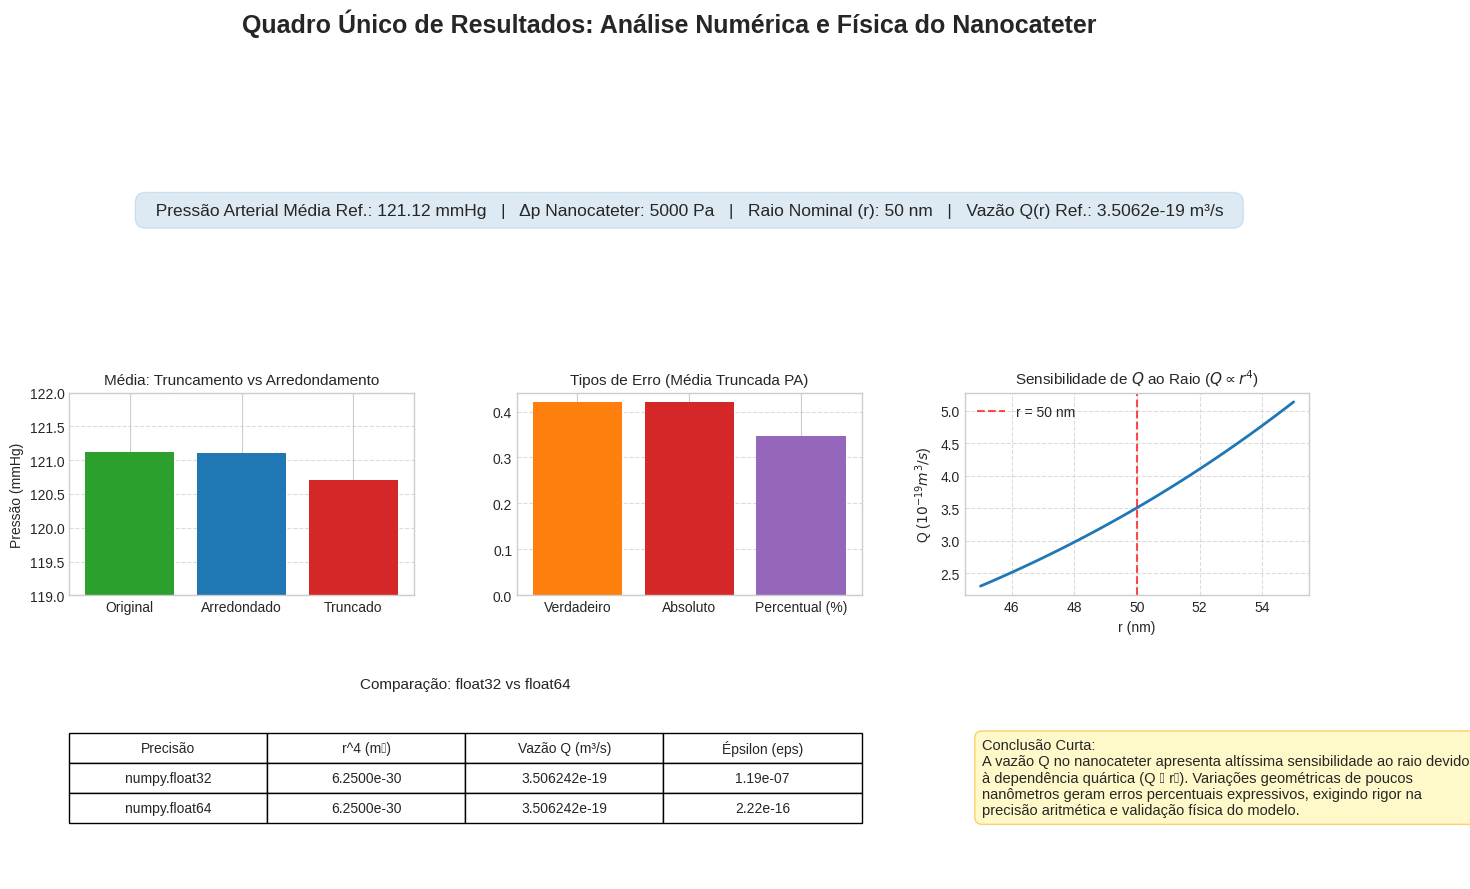

Síntese visual gerada com sucesso: 'sintese_visual.png'
GIF gerado com sucesso: 'nanocateter_demonstrativo.gif'


In [13]:
import math
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 0. FUNÇÕES E DADOS DE REFERÊNCIA DAS PARTES A, B, C e D
# ==========================================


# Função de Truncamento (Conforme equação 4 do PDF)
def truncar(x, n=0):
    fator = 10**n
    return math.floor(x * fator) / fator if x >= 0 else math.ceil(x * fator) / fator


# Função de Hagen-Poiseuille (Conforme equação 4 do PDF)
def q_hagen_poiseuille(r, L, mu, dp):
    return (np.pi * (r**4) * dp) / (8 * mu * L)


# --- Parte B: Pressão Arterial ---
dados_pa = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)
media_ref_pa = np.mean(dados_pa)  # Referência
media_arred_pa = np.mean(np.round(dados_pa))
media_trunc_pa = np.mean([truncar(v, 0) for v in dados_pa])

ev_pa = media_ref_pa - media_trunc_pa  # Erro verdadeiro
ea_pa = abs(ev_pa)  # Erro absoluto
ep_pa = (ea_pa / abs(media_ref_pa)) * 100  # Erro percentual

# --- Parte D: Nanocateter ---
r_nano = 50e-9  # 50 nm
L_nano = 10e-6  # 10 µm
mu_nano = 3.5e-3  # 3.5 mPa.s
dp_nano = 5000.0  # 5000 Pa

Q_ref_nano = q_hagen_poiseuille(r_nano, L_nano, mu_nano, dp_nano)

# float32 vs float64
r32 = np.float32(r_nano)
r64 = np.float64(r_nano)
Q32 = (np.float32(np.pi) * (r32**4) * np.float32(dp_nano)) / (
    np.float32(8) * np.float32(mu_nano) * np.float32(L_nano)
)
Q64 = q_hagen_poiseuille(r64, L_nano, mu_nano, dp_nano)


# ==========================================
# 7. PARTE E – SÍNTESE VISUAL (QUADRO ÚNICO PNG)
# ==========================================

# Configuração da figura para resolução mínima de 1600x1000 pixels
fig = plt.figure(figsize=(16, 10), dpi=100)
fig.suptitle(
    "Quadro Único de Resultados: Análise Numérica e Física do Nanocateter",
    fontsize=18,
    weight="bold",
    y=0.98,
)

gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Cartões com principais valores de pressão e vazão (KPIs)
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis("off")
kpi_text = (
    f"  Pressão Arterial Média Ref.: {media_ref_pa:.2f} mmHg   |   "
    f"Δp Nanocateter: {dp_nano:.0f} Pa   |   "
    f"Raio Nominal (r): 50 nm   |   "
    f"Vazão Q(r) Ref.: {Q_ref_nano:.4e} m³/s  "
)
ax_kpi.text(
    0.5,
    0.5,
    kpi_text,
    fontsize=12.5,
    ha="center",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.6", facecolor="#1f77b4", alpha=0.15, edgecolor="#1f77b4"
    ),
)

# 2. Comparação entre truncamento e arredondamento (Pressão Arterial)
ax_trunc = fig.add_subplot(gs[1, 0])
metodos = ["Original", "Arredondado", "Truncado"]
medias = [media_ref_pa, media_arred_pa, media_trunc_pa]
ax_trunc.bar(metodos, medias, color=["#2ca02c", "#1f77b4", "#d62728"])
ax_trunc.set_ylim(119, 122)
ax_trunc.set_title("Média: Truncamento vs Arredondamento", fontsize=11)
ax_trunc.set_ylabel("Pressão (mmHg)")
ax_trunc.grid(axis="y", linestyle="--", alpha=0.7)

# 3. Os três tipos de erro (Média Truncada da PA)
ax_erros = fig.add_subplot(gs[1, 1])
tipos_erro = ["Verdadeiro", "Absoluto", "Percentual (%)"]
valores_erro = [ev_pa, ea_pa, ep_pa]
ax_erros.bar(tipos_erro, valores_erro, color=["#ff7f0e", "#d62728", "#9467bd"])
ax_erros.set_title("Tipos de Erro (Média Truncada PA)", fontsize=11)
ax_erros.grid(axis="y", linestyle="--", alpha=0.7)

# 4. Sensibilidade de Q ao raio
ax_sens = fig.add_subplot(gs[1, 2])
r_range_nm = np.linspace(45, 55, 100)
q_range_val = q_hagen_poiseuille(
    r_range_nm * 1e-9, L_nano, mu_nano, dp_nano
)
ax_sens.plot(r_range_nm, q_range_val * 1e19, color="#1f77b4", linewidth=2)
ax_sens.axvline(50, color="red", linestyle="--", alpha=0.7, label="r = 50 nm")
ax_sens.set_title(r"Sensibilidade de $Q$ ao Raio ($Q \propto r^4$)", fontsize=11)
ax_sens.set_xlabel("r (nm)")
ax_sens.set_ylabel(r"Q ($10^{-19} m^3/s$)")
ax_sens.legend()
ax_sens.grid(True, linestyle="--", alpha=0.7)

# 5. Comparação float32 vs float64
ax_prec = fig.add_subplot(gs[2, :2])
ax_prec.axis("off")
df_table = pd.DataFrame(
    {
        "Precisão": ["numpy.float32", "numpy.float64"],
        "r^4 (m⁴)": [f"{(r32**4):.4e}", f"{(r64**4):.4e}"],
        "Vazão Q (m³/s)": [f"{Q32:.6e}", f"{Q64:.6e}"],
        "Épsilon (eps)": [
            f"{np.finfo(np.float32).eps:.2e}",
            f"{np.finfo(np.float64).eps:.2e}",
        ],
    }
)
tbl = ax_prec.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc="center",
    loc="center",
)
tbl.scale(1, 1.8)
tbl.set_fontsize(10)
ax_prec.set_title("Comparação: float32 vs float64", fontsize=11, y=0.9)

# 6. Conclusão curta sobre o nanocateter
ax_conc = fig.add_subplot(gs[2, 2])
ax_conc.axis("off")
texto_conclusao = (
    "Conclusão Curta:\n"
    "A vazão Q no nanocateter apresenta altíssima sensibilidade ao raio "
    "devido à dependência quártica (Q ∝ r⁴). Variações geométricas de "
    "poucos nanômetros geram erros percentuais expressivos, exigindo rigor "
    "na precisão aritmética e validação física do modelo."
)
ax_conc.text(
    0.05,
    0.5,
    texto_conclusao,
    fontsize=10.5,
    va="center",
    wrap=True,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#fff7bc",
        edgecolor="#fec44f",
        alpha=0.8,
    ),
)

# Salva em resolução de 1600x1000 pixels
plt.savefig("sintese_visual.png", dpi=100, bbox_inches="tight")
plt.show()
print("Síntese visual gerada com sucesso: 'sintese_visual.png'")


# ==========================================
# 8. GIF DEMONSTRATIVO (30 A 60 QUADROS)
# ==========================================

n_frames = 45  # Dentro do intervalo de 30 a 60 quadros
r_vals_nm = np.linspace(45, 55, n_frames)

fig_gif, (ax_canal, ax_curva) = plt.subplots(1, 2, figsize=(11, 5))


def animar(frame):
    ax_canal.clear()
    ax_curva.clear()

    r_atual_nm = r_vals_nm[frame]
    r_atual_m = r_atual_nm * 1e-9

    Q_atual = q_hagen_poiseuille(r_atual_m, L_nano, mu_nano, dp_nano)
    erro_perc = ((Q_atual - Q_ref_nano) / Q_ref_nano) * 100

    # 1. Seção transversal do canal
    circ_limite = plt.Circle(
        (0, 0), 55, color="#e0e0e0", fill=True, label="Limite (55 nm)"
    )
    circ_canal = plt.Circle(
        (0, 0),
        r_atual_nm,
        color="#1f77b4",
        alpha=0.7,
        fill=True,
        label="Canal Atual",
    )

    ax_canal.add_patch(circ_limite)
    ax_canal.add_patch(circ_canal)
    ax_canal.set_xlim(-60, 60)
    ax_canal.set_ylim(-60, 60)
    ax_canal.set_aspect("equal")
    ax_canal.set_title("Seção Transversal do Canal")
    ax_canal.axis("off")

    info = (
        f"Raio atual: {r_atual_nm:.2f} nm\n"
        f"Vazão Q: {Q_atual:.4e} m³/s\n"
        f"Erro relativo a 50nm: {erro_perc:+.2f}%"
    )
    ax_canal.text(
        0,
        -53,
        info,
        ha="center",
        va="center",
        fontsize=9.5,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

    # 2. Curva Q x r sendo construída progressivamente
    r_sub_nm = r_vals_nm[: frame + 1]
    Q_sub = q_hagen_poiseuille(
        r_sub_nm * 1e-9, L_nano, mu_nano, dp_nano
    )

    ax_curva.plot(
        r_sub_nm, Q_sub * 1e19, color="#1f77b4", linewidth=2.5, label="Q(r)"
    )
    ax_curva.scatter(
        [r_atual_nm],
        [Q_atual * 1e19],
        color="red",
        s=50,
        zorder=5,
        label="Ponto Atual",
    )
    ax_curva.axvline(50, color="gray", linestyle="--", alpha=0.5)

    ax_curva.set_xlim(44, 56)
    ax_curva.set_ylim(
        q_hagen_poiseuille(45e-9, L_nano, mu_nano, dp_nano) * 1e19 * 0.9,
        q_hagen_poiseuille(55e-9, L_nano, mu_nano, dp_nano) * 1e19 * 1.1,
    )
    ax_curva.set_title(r"Construção Progressiva da Curva $Q \times r$")
    ax_curva.set_xlabel("Raio $r$ (nm)")
    ax_curva.set_ylabel(r"Vazão $Q$ ($10^{-19} m^3/s$)")
    ax_curva.grid(True, linestyle="--", alpha=0.6)
    ax_curva.legend(loc="upper left")

    plt.tight_layout()


ani = animation.FuncAnimation(
    fig_gif, animar, frames=n_frames, interval=120, repeat=True
)
ani.save("nanocateter_demonstrativo.gif", writer="pillow", fps=10)
plt.close()

print("GIF gerado com sucesso: 'nanocateter_demonstrativo.gif'")